# **TASK:**

Soil moisture sensors help farmers optimize irrigation.


# **SetUp Model Environment:**

### Subtask:
Install the chosen model's libraries in the Colab environment. This may involve import and from that model you want etc.


**Reasoning:** Import the identified open-source library for fetching data and visualization and confirm

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

**Reason:** After import libraries, load dataset which is required for model and print it.

In [ ]:
df = pd.read_csv('/content/soil-moisture.csv')
print(df)

    Month  Day   avg_pm1   avg_pm2     avg_pm3    avg_am      avg_lum  \
0     Jul   18  3.548400  5.929200   24.940800  0.000000  2208.880000   
1     Jul   19  3.416827  6.403133  116.188916  0.000000  3241.160643   
2     Jul   20  3.030642  5.580000  132.736096  0.000000  3333.941176   
3     Jul   21  3.091991  5.580000  128.520000  0.000000  3523.764706   
4     Jul   22  3.129000  5.580000  128.520000  0.000000  3756.722727   
..    ...  ...       ...       ...         ...       ...          ...   
219   Mar    6  0.879412  1.175882   27.509412  1.568627  2370.686275   
220   Mar    7  0.894615  1.196154   27.549231  2.907692  2919.384615   
221   Mar    8  0.879412  1.175882   27.509412  2.525490  2928.392157   
222   Mar    9  0.894615  1.196154   27.549231  2.276923  2852.634615   
223   Mar   10  0.866522  1.207391   27.714783  1.182609  2302.434783   

      avg_temp   avg_humd     avg_pres       avg_sm  
0    21.660300  90.785900  92940.33720  7435.450000  
1    23.232932 

**Reason**: Explore the data for better understanding

In [ ]:
df["avg_sm"].fillna(df["avg_sm"].mean(), inplace=True)

/tmp/ipython-input-1285411128.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["avg_sm"].fillna(df["avg_sm"].mean(), inplace=True)


Fill the values, interpolate them

In [ ]:
df["avg_sm"] = df["avg_sm"].interpolate(method="linear")

Apply rolling feature to estimate weather conditions.

In [ ]:
df["Soil_Moisture"] = df["avg_sm"].rolling(3).median()

Take data of past days then rolling it to see trend.

In [ ]:
df["Soil_Moisture_Smoothed"] = df["avg_sm"].rolling(window=5).mean()     #Data: [10, 12, 14, 16, 18, 20]
                                                                         #Window=3 → Rolling slices:
                                                                         #[10,12,14], [12,14,16], [14,16,18], [16,18,20]
                                                                         #[10,12,14] → mean = 12

Rolling feature final code

In [ ]:
df["Moisture_1day_before"] = df["Soil_Moisture"].shift(1)                  #Soil_Moisture: [20, 22, 25, 23]
df["Moisture_3day_avg"] = df["Soil_Moisture"].rolling(3).mean()
df['Temp_7day_avg'] = df['avg_temp'].rolling(7).mean()
df['Humidity_7day_avg'] = df['avg_humd'].rolling(7).mean()                 #Rolling 3-day mean: [NaN, NaN, 22.33, 23.33]


Between current and previous day’s soil moisture

In [ ]:
df["Temp_MoistureInteraction"] = df["avg_sm"] * df["Moisture_1day_before"]#Day	avg_sm	Moisture_1day_before	Temp_MoistureInteraction
                                                                          #1	20	NaN	NaN
                                                                          #2	22	20	440


To avoid Redundancy aply categorical_cols

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns                        # Month, Day
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df_encoded.head())

   Day   avg_pm1   avg_pm2  avg_pm3    avg_am      avg_lum   avg_temp  \
0    1  1.030000  1.403333    33.52  0.800000  2452.222222  21.680952   
1    2  1.030000  1.430000    33.52  1.206349  2449.365079  21.837619   
2    3  1.019677  1.426129    33.52  0.916129  2751.709677  21.626774   
3    4  1.030000  1.403333    33.52  0.749206  2996.936508  21.198254   
4    5  1.012222  1.421111    33.52  1.828571  2574.396825  20.471429   

    avg_humd     avg_pres      avg_sm  ...  Temp_7day_avg  Humidity_7day_avg  \
0  72.911587  93672.45587  371.238095  ...            NaN                NaN   
1  68.176667  93632.49698  368.936508  ...            NaN                NaN   
2  63.535806  93652.29065  367.145161  ...            NaN                NaN   
3  63.843651  93550.34381  365.555556  ...            NaN                NaN   
4  61.808730  93608.14254  362.809524  ...            NaN                NaN   

  Month_Dec  Month_Feb  Month_Jan  Month_Jul  Month_Mar  Month_Nov  Month_Oct  \

for outlier removal use IQR( Inter - Quartile Range)

In [ ]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
def remove_outliers_iqr(df, numeric_columns):
    Q1 = df[numeric_columns].quantile(0.25)
    Q3 = df[numeric_columns].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean = df[~((df[numeric_columns] < lower_bound) | (df[numeric_columns] > upper_bound)).any(axis=1)]
    return df_clean
data_clean = remove_outliers_iqr(df, numeric_cols)
print("Original data shape:",df.shape)
print("Data shape after outlier removal:", data_clean.shape)

Original data shape: (224, 14)
Data shape after outlier removal: (198, 14)


In [ ]:
rolling_window = 3
for col in numeric_cols:
    data_clean[f'{col}_roll_mean'] = data_clean[col].rolling(window=rolling_window, min_periods=1).mean() #Day values:20, 22, 23, 25
                                                                                                          #3-day rolling mean:
                                                                                                          #Day1: 20  only 1 value
                                                                                                          #Day2: 22  average of 20+22
                                                                                                          #Day3: 21.67 average of 20+22+21.67
                                                                                                          #Day4: 23.33 average of 22+21.67+23.33
    data_clean[f'{col}_roll_std'] = data_clean[col].rolling(window=rolling_window, min_periods=1).std().fillna(0)
                                                                                                          #Day values: 20, 22, 23
                                                                                                          #3-day rolling std:
                                                                                                          #Day1: 0  only 1 value
                                                                                                          #Day2: 1.414 std of 20,22
                                                                                                          #Day3: 1.527    (std of 20,22,23)

/tmp/ipython-input-3717868841.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean[f'{col}_roll_mean'] = data_clean[col].rolling(window=rolling_window, min_periods=1).mean() #Day values:20, 22, 23, 25
/tmp/ipython-input-3717868841.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean[f'{col}_roll_std'] = data_clean[col].rolling(window=rolling_window, min_periods=1).std().fillna(0)
/tmp/ipython-input-3717868841.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

Before Training visualization

avg_sm
342.344828    2
368.936508    1
367.145161    1
365.555556    1
371.238095    1
             ..
380.888889    1
379.714286    1
377.612903    1
376.206349    1
373.677419    1
Name: count, Length: 197, dtype: int64


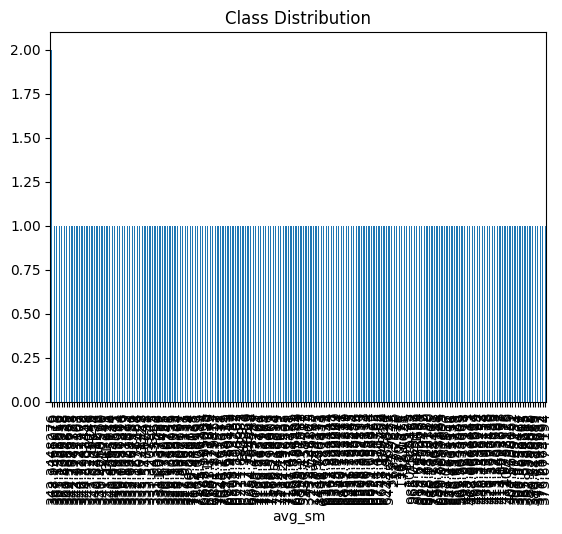

In [ ]:
print(data_clean['avg_sm'].value_counts())
data_clean['avg_sm'].value_counts().plot(kind='bar', title='Class Distribution')
plt.show()

Display X-features and y-target

In [ ]:
X = df.drop("Soil_Moisture", axis=1)
y = df["Soil_Moisture"]
categorical_cols = ['Month']
ct = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(drop='first', handle_unknown='ignore'), ["Month"]),
        ("scale", MinMaxScaler(), ["avg_temp", "avg_sm"])
    ]
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)


Linear Regression

In [ ]:
df["Moisture_1day_before"] = df["Soil_Moisture"].shift(1)
df["Moisture_3day_avg"] = df["Soil_Moisture"].rolling(3).mean()
df = df.dropna()
X = df[["Moisture_1day_before", "Moisture_3day_avg"]]
y = df["avg_sm"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression R2: 0.9607665006386907


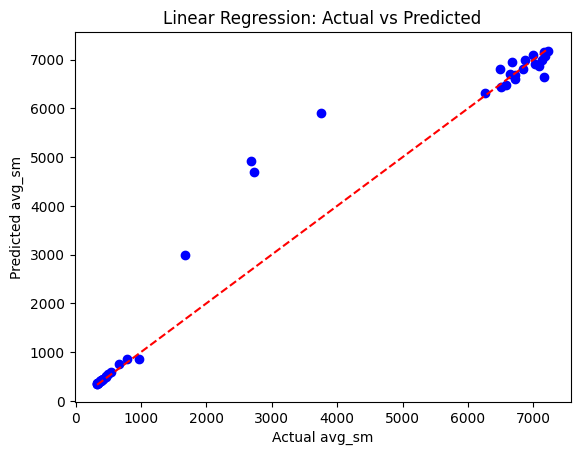

In [ ]:
df_vis = pd.DataFrame({
    "Actual": y_test,
    "LR_Pred": y_pred_lr,
})
plt.figure()
plt.scatter(df_vis["Actual"], df_vis["LR_Pred"], color='blue')
plt.plot([df_vis["Actual"].min(), df_vis["Actual"].max()],
         [df_vis["Actual"].min(), df_vis["Actual"].max()],
         color='red', linestyle='--')
plt.xlabel("Actual avg_sm")
plt.ylabel("Predicted avg_sm")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

Support Vector Regressor

In [ ]:
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
svr = SVR(kernel='rbf', C=100, gamma=0.1)
svr.fit(X_train_std, y_train)
y_pred_svr = svr.predict(X_test_std)
print("SVR R2:", r2_score(y_test, y_pred_svr))

SVR R2: 0.9530658595332401


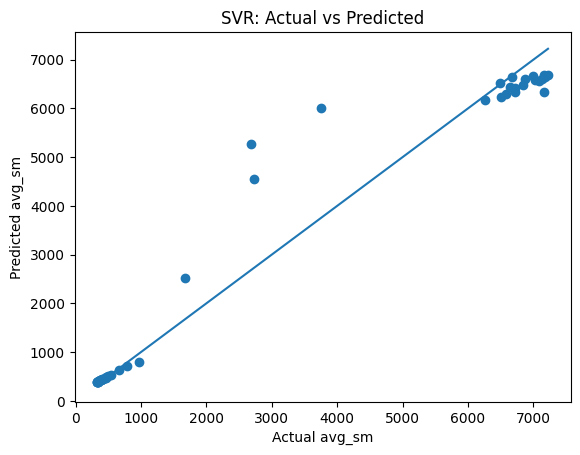

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred_svr)
plt.xlabel("Actual avg_sm")
plt.ylabel("Predicted avg_sm")
plt.title("SVR: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

Decision Tree R2_Score

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))

Decision Tree R2: 0.9814497775192096


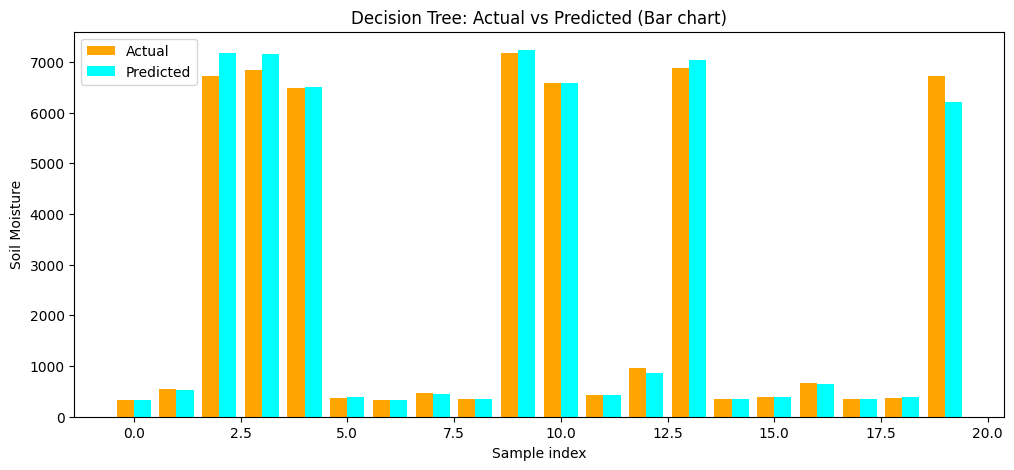

In [ ]:
df_vis = pd.DataFrame({
    "Actual": y_test,
    "DT_Pred": y_pred_dt,
})
plt.figure(figsize=(12,5))
plt.bar(np.arange(20)-0.2, df_vis["Actual"].values[:20], width=0.4, label='Actual', color='orange')
plt.bar(np.arange(20)+0.2, df_vis["DT_Pred"].values[:20], width=0.4, label='Predicted', color='cyan')
plt.xlabel("Sample index")
plt.ylabel("Soil Moisture")
plt.title("Decision Tree: Actual vs Predicted (Bar chart)")
plt.legend()
plt.show()

Random forest R2_score

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.9695683672242502


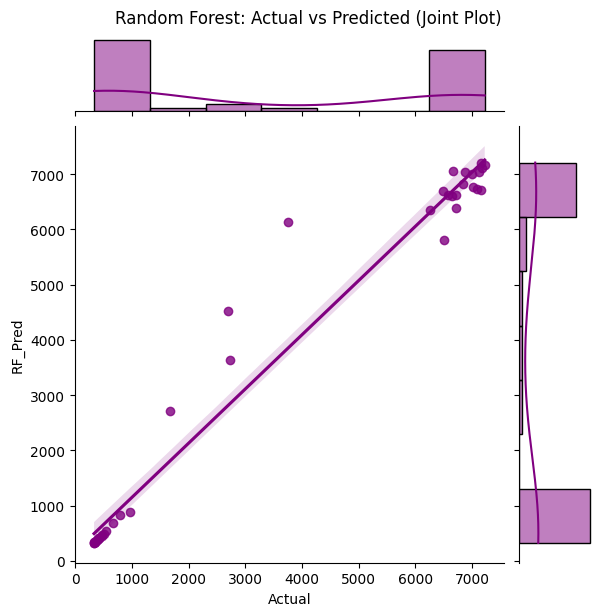

In [ ]:
df_vis = pd.DataFrame({
    "Actual": y_test,
    "RF_Pred": y_pred_rf
})
sns.jointplot(x="Actual", y="RF_Pred", data=df_vis, kind='reg', color='purple')
plt.suptitle("Random Forest: Actual vs Predicted (Joint Plot)", y=1.02)
plt.show()

K-Neighbour Regressor

In [ ]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Regressor R2:", r2_score(y_test, y_pred_knn))

KNN Regressor R2: 0.9538384270871585


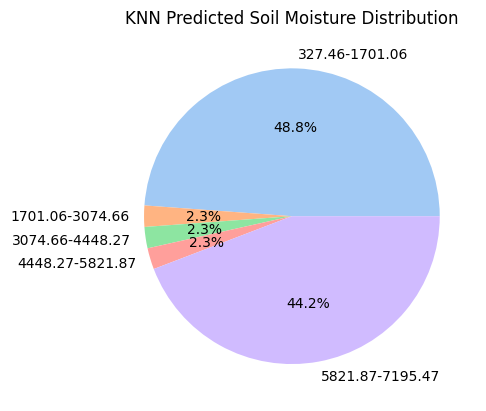

In [ ]:
df_vis = pd.DataFrame({
    "Actual": y_test,
    "KNN_Pred": y_pred_knn
})

knn_counts, bins = np.histogram(df_vis["KNN_Pred"], bins=5)
plt.figure()
plt.pie(knn_counts, labels=[f"{round(bins[i],2)}-{round(bins[i+1],2)}" for i in range(len(bins)-1)],
        autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("KNN Predicted Soil Moisture Distribution")
plt.show()

ANN Deep Learning

In [ ]:
model = Sequential()
model.add(Dense(8, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(4, activation='relu'))
model.add(Dense(1))
model.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
X = df[["avg_temp", "avg_humd", "Moisture_1day_before"]]
y = df["avg_sm"]

In [ ]:
scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler.transform(y_test.values.reshape(-1,1))

Prediction

In [ ]:
model_ann = Sequential()
model_ann.add(Dense(8, activation='relu', input_shape=(X_train.shape[1],)))
model_ann.add(Dense(4, activation='relu'))
model_ann.add(Dense(1))
model_ann.compile(optimizer='adam', loss='mse')
model_ann.fit(X_train, y_train_scaled, epochs=50, batch_size=16, validation_split=0.1)
y_pred_scaled = model_ann.predict(X_test)
y_pred_ann = scaler.inverse_transform(y_pred_scaled)
y_pred_ann = y_pred_ann.flatten()
print("ANN R2:", r2_score(y_test, y_pred_ann))
mae = mean_absolute_error(y_test, y_pred_ann)
print("Mean Absolute Error:", mae)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - loss: 0.4599 - val_loss: 0.6006
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.4248 - val_loss: 0.5684
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4072 - val_loss: 0.5389
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4096 - val_loss: 0.5110
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3991 - val_loss: 0.4869
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3492 - val_loss: 0.4677
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.3398 - val_loss: 0.4489
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.3397 - val_loss: 0.4323
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.3410 - val_loss: 0.4160
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2790 - val_loss: 0.3965
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2866 - val_loss: 0.3707
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2532 - val_loss: 0.3485


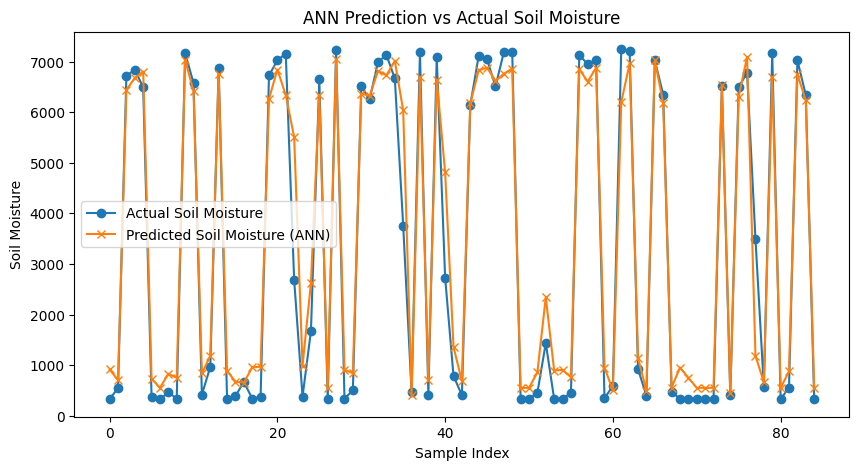

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Soil Moisture", marker='o')
plt.plot(y_pred_ann, label="Predicted Soil Moisture (ANN)", marker='x')
plt.title("ANN Prediction vs Actual Soil Moisture")
plt.xlabel("Sample Index")
plt.ylabel("Soil Moisture")
plt.legend()
plt.show()

In [ ]:
temp = float(input("Enter Temperature: "))
Pressure= float(input("Enter Pressure: "))
humidity = float(input("Enter Humidity: "))
user_input = np.array([[temp,Pressure, humidity]])
user_input_scaled = user_input
predicted_moisture = model_ann.predict(user_input_scaled)[0][0]
if predicted_moisture > 0:
    print(f"Soil Moisture exists! Predicted value: {predicted_moisture:.2f}")
else:
    print("No soil moisture detected!")

Enter Temperature: 23
Enter Pressure: 34
Enter Humidity: 35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Soil Moisture exists! Predicted value: 14.17


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
extract_path = '/content/soil_dataset'
os.makedirs(extract_path, exist_ok=True)


In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'OW-f23-m.pdf',
 'Misbah_Hussain_CV',
 'Assignments of AI.docx',
 'ANAS 2.docx',
 'Work_Projects',
 'Google Sheet.gsheet',
 'Customer Feedback (File responses)',
 'Customer Feedback.gform',
 'Untitled project (2).gscript',
 'Untitled project (1).gscript',
 'PDFs',
 'Organized_PDF.gscript',
 'social media',
 'DS lab.zip',
 'Copy of DS lab.zip',
 'DS LAB',
 'My_Resume.gdoc',
 'Misbah_Hussain_CV (4).pdf',
 'Misbah_Hussain_CV (3).pdf',
 'Misbah_Hussain_CV (2).pdf',
 'Misbah_Hussain_CV (1).pdf',
 'Misbah_Hussain_CV.pdf',
 'Motivation_Letter.pdf',
 'MISBAH HUSSAIN Transcript (2).pdf',
 'MISBAH HUSSAIN Transcript (1).pdf',
 'WhatsApp Image 2025-05-18 at 9.58.31 AM.jpeg',
 'Trascripts_GPA',
 'Misbah_Hussain_CV (1).docx',
 'Misbah_Hussain_CV.docx',
 'people-100.csv',
 'people-100.gsheet',
 'Misbah_Hussain_CV_ (12).pdf',
 'Misbah_Hussain_CV_ (11).pdf',
 'Misbah_Hussain_CV_ (10).pdf',
 'Misbah_Hussain_CV_ (9).pdf',
 'Misbah_Hussain_CV_ (8).pdf',
 'Misbah_Hussain_CV_ (7).pdf',

In [ ]:
zip_path = '/content/drive/MyDrive/Soil_Moisture_Dataset_for_Image_Based_Soil_Classification (1).zip'

import os
print("ZIP exists:", os.path.exists(zip_path))


ZIP exists: True


In [ ]:
import zipfile
extract_path = '/content/soil_dataset'
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("✅ ZIP extracted successfully")


✅ ZIP extracted successfully


In [ ]:
import zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("✅ Dataset extraction done!")

✅ Dataset extraction done!


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print("📁 Folder:", root)
    print("Files:", files[:10])  # first 10 files
    break


📁 Folder: /content/soil_dataset
Files: []


In [ ]:
zip_path = '/content/drive/MyDrive/Soil_Moisture_Dataset_for_Image_Based_Soil_Classification (1).zip'
extract_path = '/content/soil_dataset'
os.makedirs(extract_path, exist_ok=True)
print("ZIP exists:", os.path.exists(zip_path))

ZIP exists: True


In [ ]:
import zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("✅ Dataset extraction done!")


✅ Dataset extraction done!


In [ ]:
import os
extract_path = '/content/soil_dataset'

for root, dirs, files in os.walk(extract_path):
    print("Folder:", root)
    print("Number of files:", len(files))
    print("First 5 files:", files[:5])


Folder: /content/soil_dataset
Number of files: 0
First 5 files: []
Folder: /content/soil_dataset/Soil_Moisture_Dataset
Number of files: 0
First 5 files: []
Folder: /content/soil_dataset/Soil_Moisture_Dataset/After Augmentation
Number of files: 0
First 5 files: []
Folder: /content/soil_dataset/Soil_Moisture_Dataset/After Augmentation/dry
Number of files: 3611
First 5 files: ['aug_168_7375886.jpg', 'aug_147_6094067.jpg', 'aug_368_1731649.jpg', 'aug_279_5169619.jpg', 'aug_12_6132510.jpg']
Folder: /content/soil_dataset/Soil_Moisture_Dataset/After Augmentation/wet
Number of files: 3974
First 5 files: ['aug_167_9665235.jpg', 'aug_334_3731205.jpg', 'aug_264_6493442.jpg', 'aug_167_2946267.jpg', 'aug_290_5927423.jpg']
Folder: /content/soil_dataset/Soil_Moisture_Dataset/After Augmentation/moderate
Number of files: 3872
First 5 files: ['aug_355_7362661.jpg', 'aug_234_6320914.jpg', 'aug_340_5884737.jpg', 'aug_331_3776021.jpg', 'aug_96_933898.jpg']
Folder: /content/soil_dataset/Soil_Moisture_Datase

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path to main folder containing class folders
data_dir = '/content/soil_dataset/Soil_Moisture_Dataset/After Augmentation'

# ImageDataGenerator with validation split
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Training generator
train_gen = datagen.flow_from_directory(
    directory=data_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
val_gen = datagen.flow_from_directory(
    directory=data_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 9167 images belonging to 3 classes.
Found 2290 images belonging to 3 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')  # dry, wet, moderate
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    steps_per_epoch=train_gen.samples // train_gen.batch_size,
    validation_steps=val_gen.samples // val_gen.batch_size
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 345s 1s/step - accuracy: 0.4887 - loss: 0.9692 - val_accuracy: 0.6840 - val_loss: 0.6363
Epoch 2/10
  1/286 ━━━━━━━━━━━━━━━━━━━━ 6:49 1s/step - accuracy: 0.6875 - loss: 0.7827

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


286/286 ━━━━━━━━━━━━━━━━━━━━ 37s 126ms/step - accuracy: 0.6875 - loss: 0.7827 - val_accuracy: 0.6844 - val_loss: 0.6674
Epoch 3/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 334s 1s/step - accuracy: 0.6173 - loss: 0.8125 - val_accuracy: 0.6765 - val_loss: 0.6443
Epoch 4/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 37s 124ms/step - accuracy: 0.5938 - loss: 0.7239 - val_accuracy: 0.6686 - val_loss: 0.6833
Epoch 5/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 347s 1s/step - accuracy: 0.6424 - loss: 0.7640 - val_accuracy: 0.7051 - val_loss: 0.6326
Epoch 6/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 41s 141ms/step - accuracy: 0.7188 - loss: 0.6610 - val_accuracy: 0.7165 - val_loss: 0.5915
Epoch 7/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - accuracy: 0.6913 - loss: 0.6794 - val_accuracy: 0.7161 - val_loss: 0.6142
Epoch 8/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 42s 142ms/step - accuracy: 0.8125 - loss: 0.5965 - val_accuracy: 0.6250 - val_loss: 0.7961
Epoch 9/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 338s 1s/step - accuracy: 0.7323 - loss: 0.6027 - val_accurac

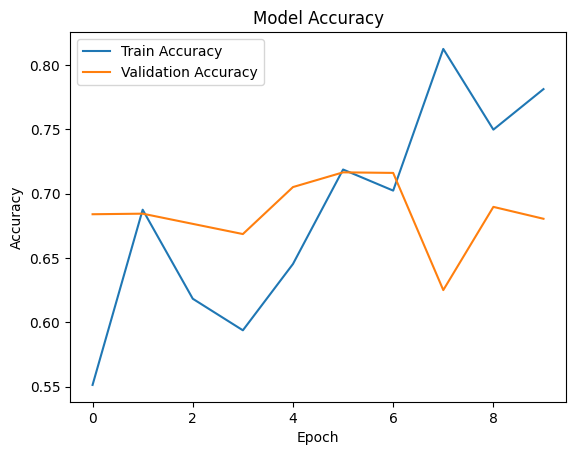

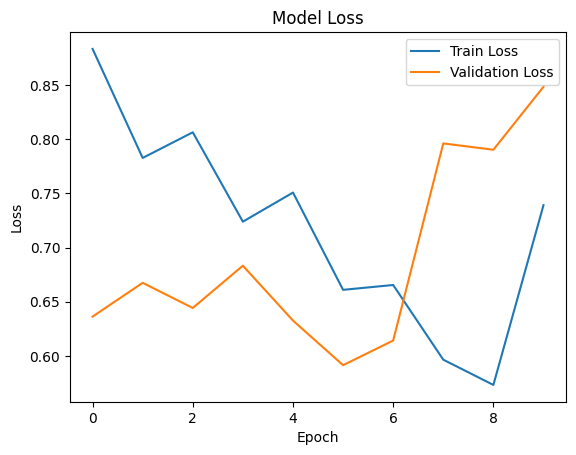

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
class_labels = list(train_gen.class_indices.keys())
def predict_soil(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0) / 255.0
    pred = model.predict(x)
    class_idx = np.argmax(pred, axis=1)[0]
    return class_labels[class_idx]

In [ ]:
    prediction = model.predict(img_arr)
    predicted_class = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


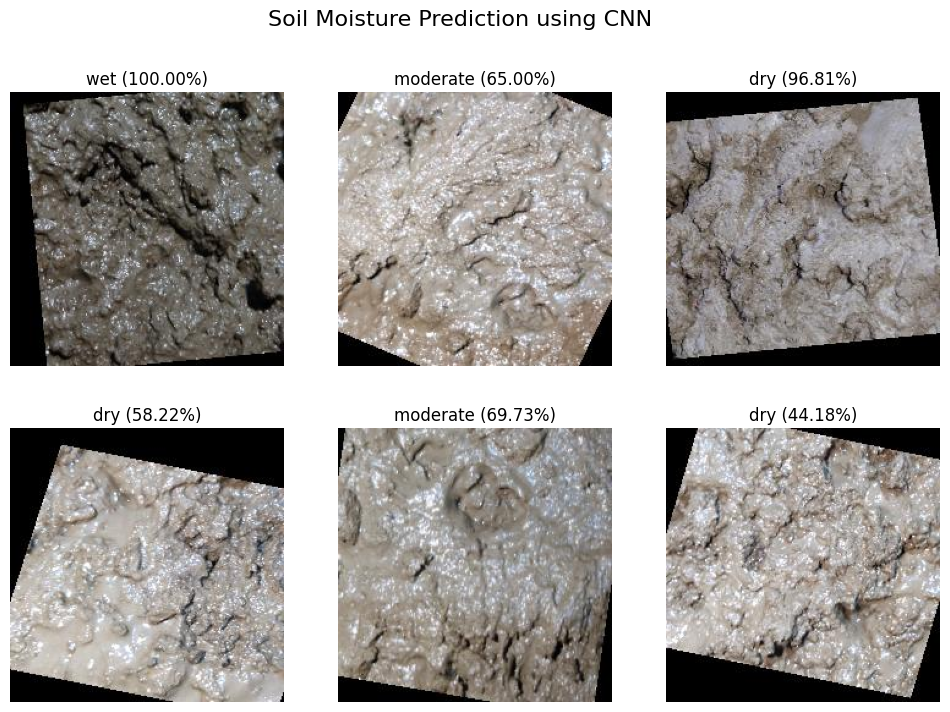

In [ ]:
import os, random
from PIL import Image

data_dir = '/content/soil_dataset/Soil_Moisture_Dataset/After Augmentation'

# collect all images
all_images = []
for root, dirs, files in os.walk(data_dir):
    for f in files:
        if f.lower().endswith(('.jpg','.png')):
            all_images.append(os.path.join(root, f))

# show 6 images with prediction
plt.figure(figsize=(12,8))

for i in range(6):
    img_path = random.choice(all_images)
    pred, conf = predict_soil(img_path)

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"{pred} ({conf:.2f}%)")
    plt.axis('off')

plt.suptitle("Soil Moisture Prediction using CNN", fontsize=16)
plt.show()


Enter soil condition (dry / wet / moderate): WET
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


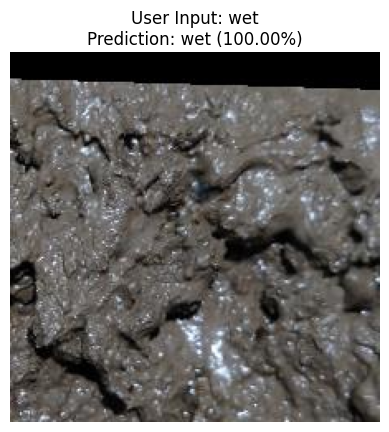

In [ ]:
user_condition = input("Enter soil condition (dry / wet / moderate): ").lower()

filtered_images = [img for img in all_images if f"/{user_condition}/" in img]

if len(filtered_images) == 0:
    print("❌ No images found for this condition")
else:
    img_path = random.choice(filtered_images)
    pred, conf = predict_soil(img_path)

    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"User Input: {user_condition}\nPrediction: {pred} ({conf:.2f}%)")
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


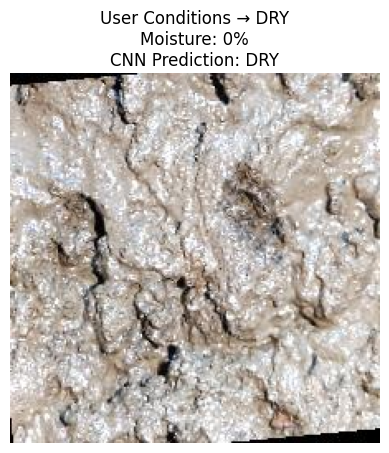

In [ ]:
import os, random
import matplotlib.pyplot as plt
from PIL import Image

data_dir = '/content/soil_dataset/Soil_Moisture_Dataset/After Augmentation'

# collect images of predicted soil type
matched_images = []

for root, dirs, files in os.walk(data_dir):
    if soil_type in root.lower():
        for f in files:
            if f.lower().endswith(('.jpg','.png')):
                matched_images.append(os.path.join(root, f))

# show image
if len(matched_images) > 0:
    img_path = random.choice(matched_images)
    cnn_result = cnn_predict(img_path)

    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f"User Conditions → {soil_type.upper()}\n"
        f"Moisture: {moisture_value}%\n"
        f"CNN Prediction: {cnn_result.upper()}"
    )
    plt.show()
else:
    print("No images found for this soil condition")


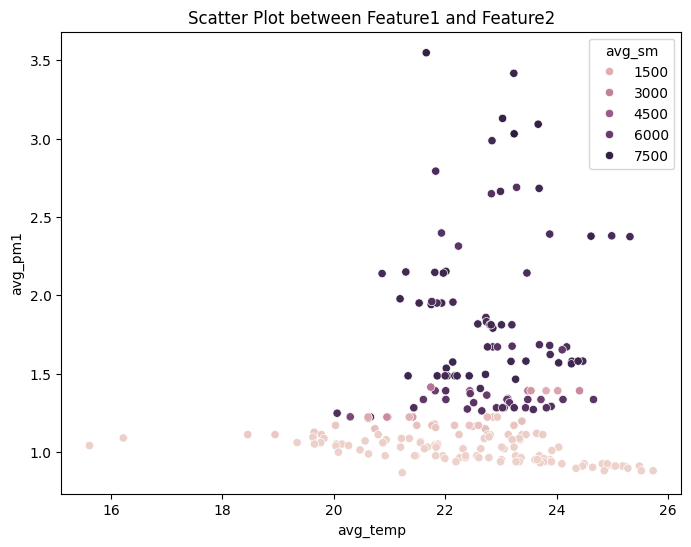

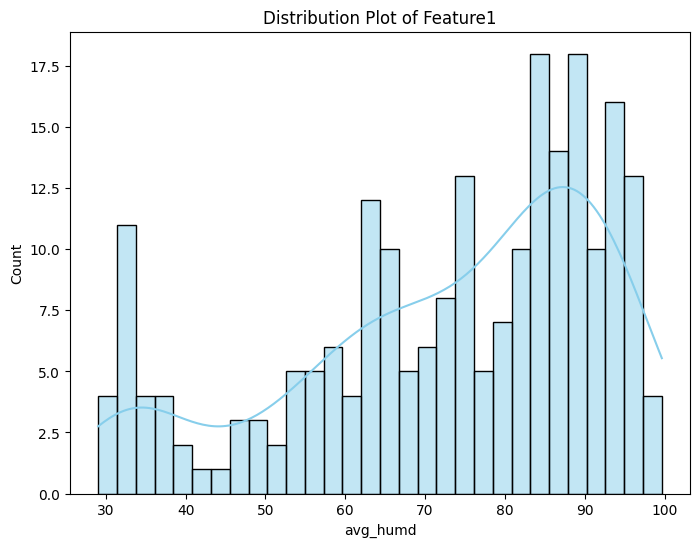

In [ ]:
# Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset (replace 'your_dataset.csv' with actual filename)
df = pd.read_csv('/content/soil-moisture.csv')

# 1️⃣ Scatter Plot Example
# Let's assume two columns: 'Feature1' and 'Feature2'
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='avg_temp', y='avg_pm1', hue='avg_sm')  # replace 'Target' if exists
plt.title('Scatter Plot between Feature1 and Feature2')
plt.show()

# 2️⃣ Distribution Plot Example
# For a numeric column 'Feature1'
plt.figure(figsize=(8,6))
sns.histplot(df['avg_humd'], kde=True, bins=30, color='skyblue')
plt.title('Distribution Plot of Feature1')
plt.show()
